## 1. IMPORTS

In [1]:
# ======================================
# 1. IMPORTS
# ======================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report, roc_auc_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import sys
sys.path.append(os.path.abspath(".."))

from src.features import feature_engineering

import joblib

## 2. CARREGAMENTO DOS DADOS

In [2]:
# ======================================
# 2. CARREGAMENTO DOS DADOS
# ======================================

train_path = "../data/raw/cs-training.csv"

df = pd.read_csv(train_path)

df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 3. LIMPEZA E PREPARAÇÃO

In [3]:
# ======================================
# 3. LIMPEZA E PREPARAÇÃO
# ======================================

# Remover coluna inútil
df = df.drop(columns=['Unnamed: 0'])

# Renomear colunas
df.columns = [
    'target',
    'credit_utilization',
    'age',
    'late_30_59_days',
    'debt_ratio',
    'monthly_income',
    'open_credit_lines',
    'late_90_days',
    'real_estate_loans',
    'late_60_89_days',
    'dependents'
]

# Tratar valores faltantes
df['monthly_income'] = df['monthly_income'].fillna(df['monthly_income'].median())
df['dependents'] = df['dependents'].fillna(df['dependents'].median())

df.isnull().sum()

target                0
credit_utilization    0
age                   0
late_30_59_days       0
debt_ratio            0
monthly_income        0
open_credit_lines     0
late_90_days          0
real_estate_loans     0
late_60_89_days       0
dependents            0
dtype: int64

## 4. EDA (SEM ALTERAR O DF)

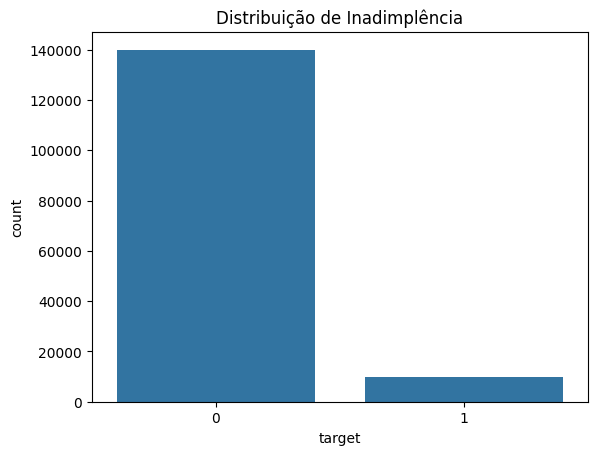

target
0    0.93316
1    0.06684
Name: proportion, dtype: float64


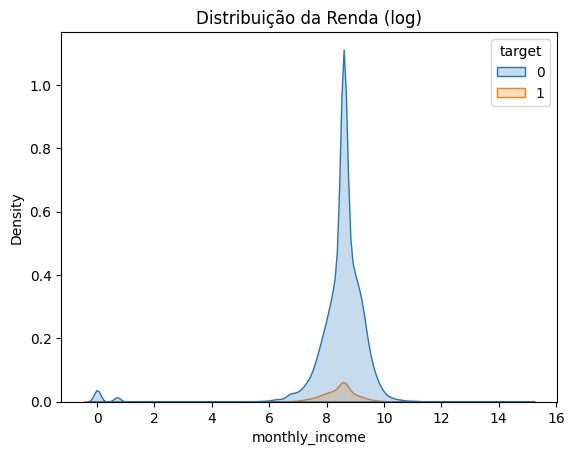

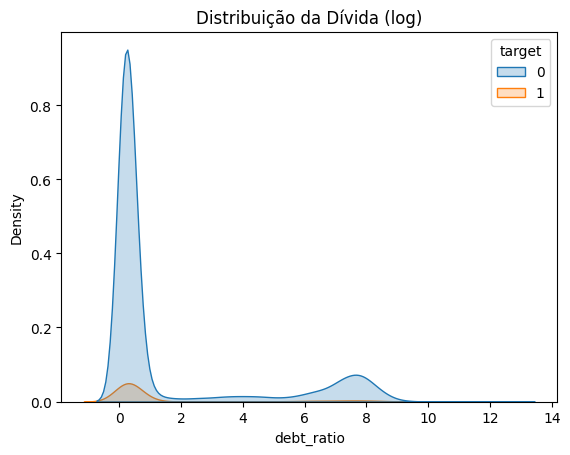

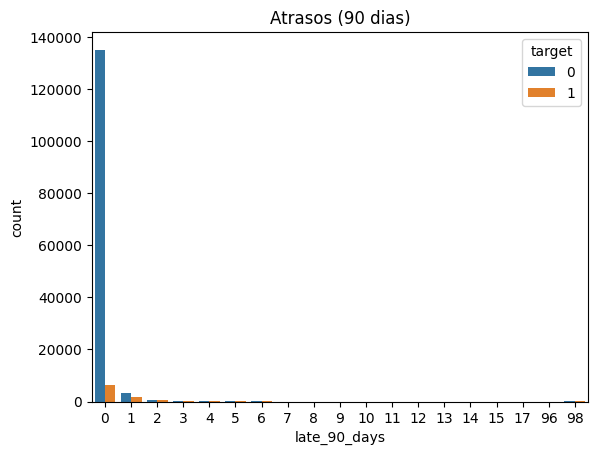

In [4]:
# ======================================
# 4. EDA
# ======================================

sns.countplot(x='target', data=df)
plt.title('Distribuição de Inadimplência')
plt.show()

print(df['target'].value_counts(normalize=True))

# Renda (log apenas para visualização)
sns.kdeplot(x=np.log1p(df['monthly_income']), hue=df['target'], fill=True)
plt.title('Distribuição da Renda (log)')
plt.show()

# Dívida (log)
sns.kdeplot(x=np.log1p(df['debt_ratio']), hue=df['target'], fill=True)
plt.title('Distribuição da Dívida (log)')
plt.show()

# Atrasos
sns.countplot(x='late_90_days', hue='target', data=df)
plt.title('Atrasos (90 dias)')
plt.show()

## 5. SPLIT DOS DADOS

In [5]:
# ======================================
# 5. SPLIT DOS DADOS
# ======================================

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 6. FEATURE ENGINEERING (NO PIPELINE)

In [6]:
# ======================================
# 6. FEATURE ENGINEERING
# ======================================



## 7. PIPELINE + MODEL

In [7]:
# ======================================
# 7. PIPELINE
# ======================================

pipeline = Pipeline([
    ('feature_engineering', FunctionTransformer(feature_engineering)),
    ('model', RandomForestClassifier(
        class_weight={0:1, 1:3},
        random_state=42,
        n_jobs=-1
    ))
])

## 8. TUNING

In [8]:
# ======================================
# 8. GRID SEARCH
# ======================================

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [4, 6, 8],
    'model__min_samples_split': [20, 50, 100]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)

Melhores parâmetros: {'model__max_depth': 8, 'model__min_samples_split': 100, 'model__n_estimators': 200}


## 9. CALIBRAÇÃO

In [9]:
# ======================================
# 9. CALIBRAÇÃO
# ======================================

calibrated_model = CalibratedClassifierCV(
    grid.best_estimator_,
    method='isotonic',
    cv=3
)

calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...0029122FEF1A0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity functio

## 10. CURVA DE CALIBRAÇÃO


Probabilidade média prevista: 0.14036354720952382
Taxa real: 0.06683333333333333


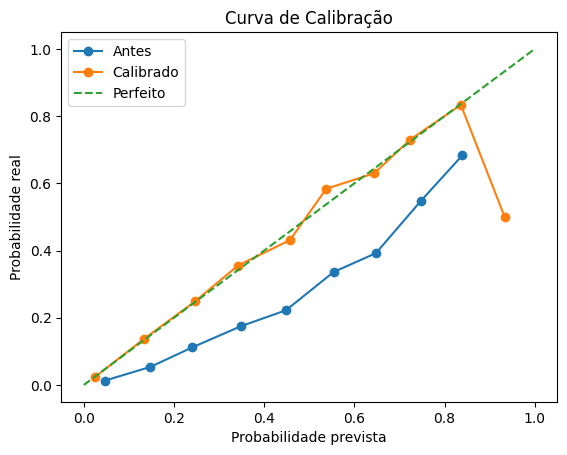

In [10]:
# ======================================
# 10. CURVA DE CALIBRAÇÃO
# ======================================

y_prob = grid.predict_proba(X_test)[:, 1]
y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=10)

print("\nProbabilidade média prevista:", y_prob.mean())
print("Taxa real:", y_test.mean())

plt.plot(prob_pred, prob_true, marker='o', label='Antes')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='Calibrado')
plt.plot([0,1], [0,1], linestyle='--', label='Perfeito')

plt.xlabel('Probabilidade prevista')
plt.ylabel('Probabilidade real')
plt.title('Curva de Calibração')

plt.legend()
plt.show()

## 11. AVALIAÇÃO

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.63      0.19      0.29      2005

    accuracy                           0.94     30000
   macro avg       0.79      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000


ROC AUC: 0.8649844401320328


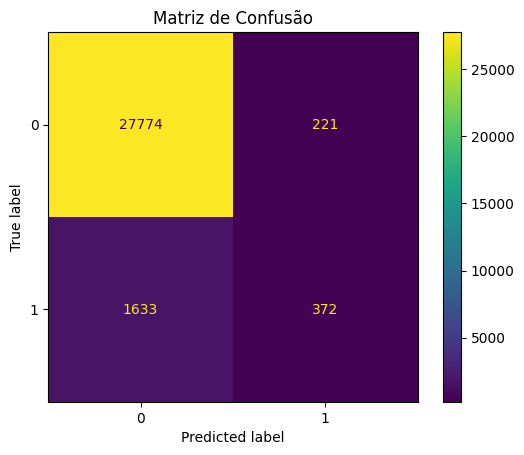

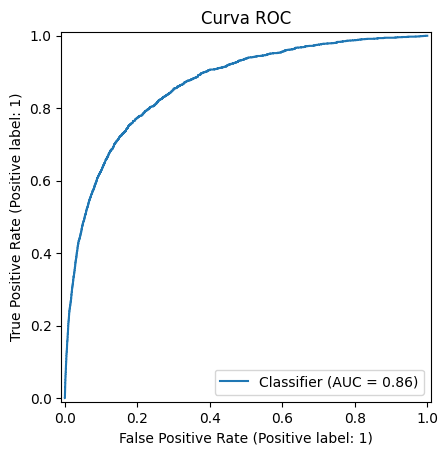

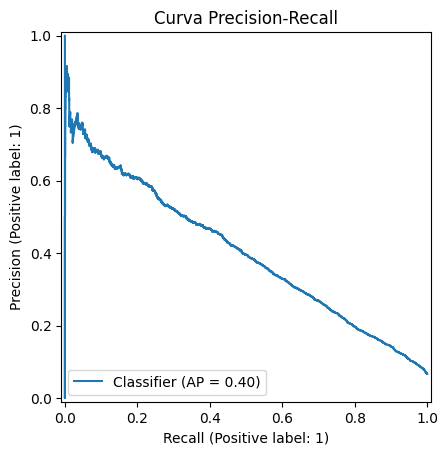

In [11]:
# ======================================
# 11. AVALIAÇÃO
# ======================================

# predição de classe
y_pred = calibrated_model.predict(X_test)

# probabilidade
y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\nROC AUC:", roc_auc_score(y_test, y_prob))

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Matriz de Confusão')
plt.show()

# ROC Curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('Curva ROC')
plt.show()

# Precision-Recall
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title('Curva Precision-Recall')
plt.show()

## 12. IMPORTÂNCIA DAS FEATURES

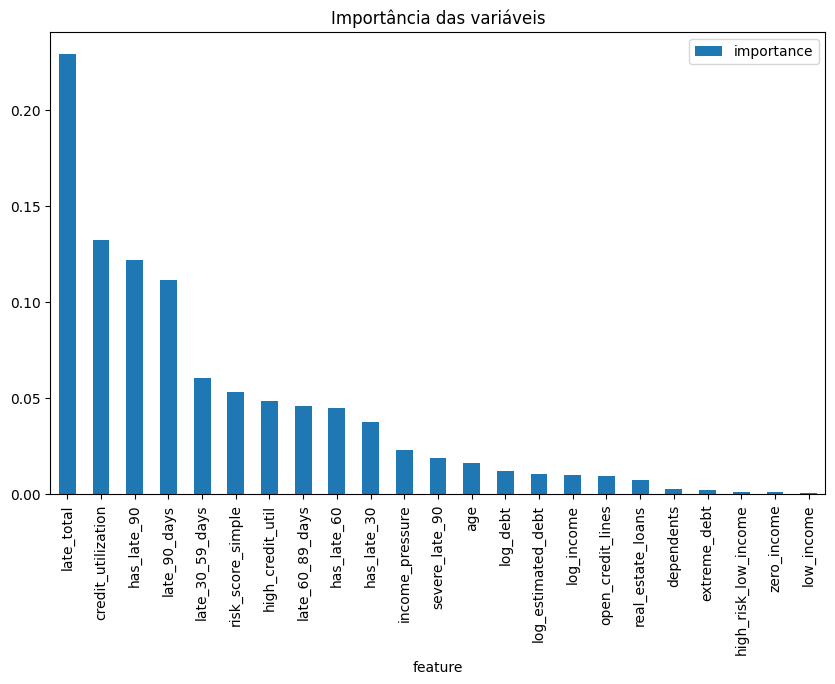

In [12]:
# ======================================
# 12. IMPORTÂNCIA
# ======================================

# usar modelo ANTES da calibração
best_pipeline = grid.best_estimator_

X_transformed = best_pipeline.named_steps['feature_engineering'].transform(X_train)

rf_model = best_pipeline.named_steps['model']

importances = rf_model.feature_importances_

feature_names = X_transformed.columns

feat_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_importance

feat_importance.set_index('feature').plot(kind='bar', figsize=(10,6))
plt.title('Importância das variáveis')
plt.show()

## 13. SHAP

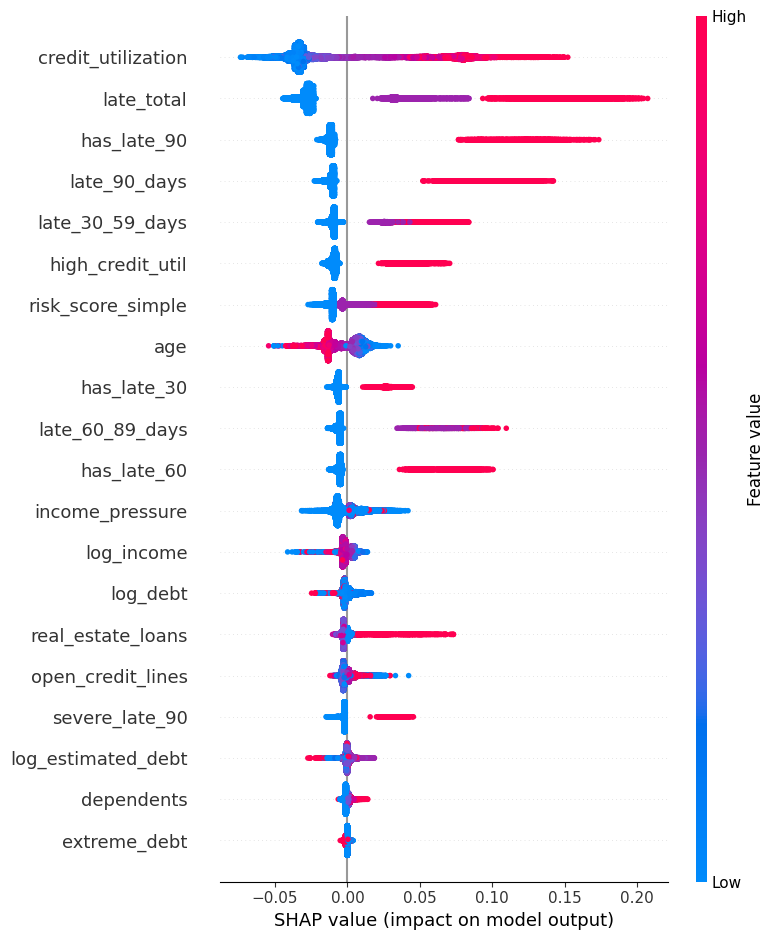

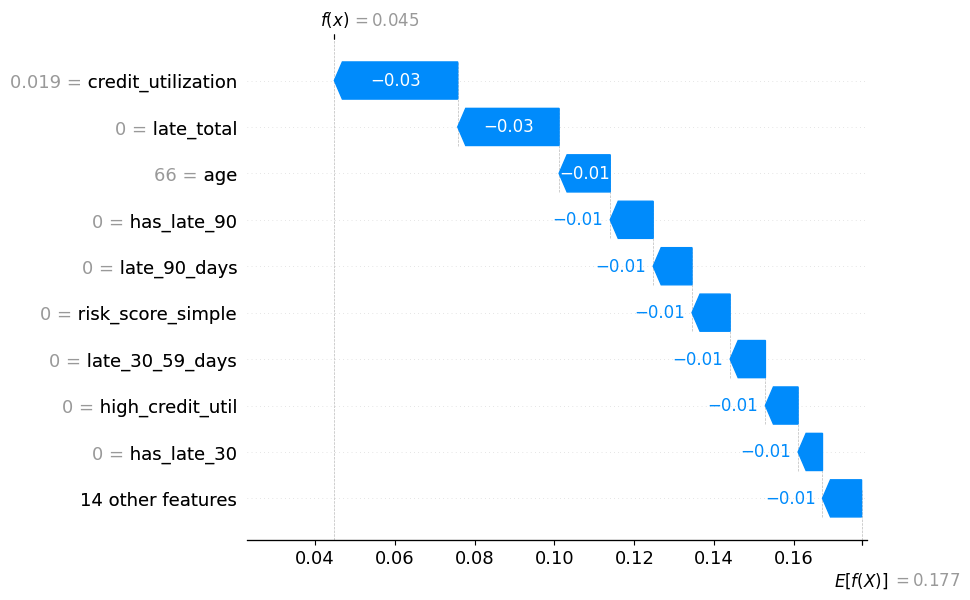

In [13]:
# ======================================
# 13. SHAP (EXPLICAÇÃO)
# ======================================

pipeline_model = grid.best_estimator_
rf_model = pipeline_model.named_steps['model']

X_transformed = pipeline_model.named_steps['feature_engineering'].transform(X_test)

# Explainer rápido
explainer = shap.TreeExplainer(rf_model)

# SHAP values
shap_values = explainer(X_transformed)

# GLOBAL
shap.summary_plot(shap_values[:, :, 1], X_transformed)

# LOCAL (cliente específico)
i = 0
shap.plots.waterfall(shap_values[i, :, 1])

## 14. SALVAR MODELO

In [14]:
# ======================================
# 11. EXPORTAÇÃO
# ======================================

joblib.dump(calibrated_model, '../model/model.pkl')

['../model/model.pkl']